In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
import h5py
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [2]:
beta = 10.0

DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
scale_factor = 1
FILE_PATH = DATA_DIR / f"2D_DarcyFlow_beta10.0_Train_Scale{scale_factor}.hdf5"

In [3]:
epochs = 300
M = 256
chunk_size = 256 
hidden_layers = [128, 128, 128, 128] 

# Set total_features depending on which architecture is uncommented below.
# total_features = hidden_layers[-1] # For Architecture 2 (Single Output)
total_features = (2 * M) + sum(hidden_layers) # For Architecture 1 (Concatenated Output)

# Kaczmarz Settings (from Poisson Gauss)
kaczmarz_sweeps = 20
kaczmarz_alpha = 0.3
kaczmarz_tik_reg = 1e-5 # Brought over from Darcy

# Loss weights (from Darcy)
matrix_bc_weight = 1e4
pde_loss_weight = 1.0
bc_loss_weight = 1e3
data_loss_weight = 0

print(f"Total Features configured: {total_features}")

# total_features to be perfectly divisible by chunk_size for jax.lax.scan loops to work
if total_features % chunk_size != 0:
    raise ValueError(
        f"total_features ({total_features}) must be divisible by "
        f"chunk_size ({chunk_size})"
    )

Total Features configured: 1024


--- Numerical Sanity Checks (Sample 0) ---
Contains NaNs: False
Max absolute value on u boundaries: 6.040051e-01 (Should be ~0.0)


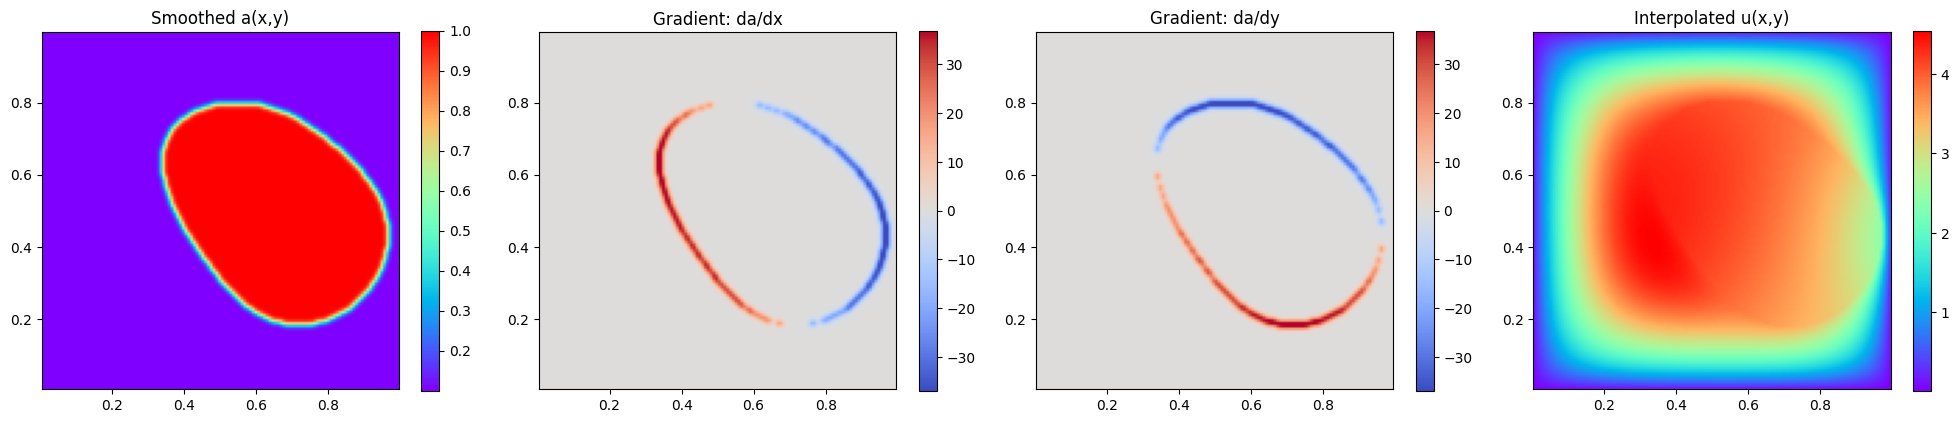

In [4]:
sample_idx = 0

with h5py.File(FILE_PATH, 'r') as f:
    # 1. Get grid dimensions
    fine_x = f['x-coordinate'][:]
    fine_y = f['y-coordinate'][:]
    fine_nx, fine_ny = len(fine_x), len(fine_y)
    
    # 2. Extract the sample and reshape back to 2D
    a_2d = f['a_flat'][sample_idx].reshape(fine_nx, fine_ny)
    ax_2d = f['a_x_flat'][sample_idx].reshape(fine_nx, fine_ny)
    ay_2d = f['a_y_flat'][sample_idx].reshape(fine_nx, fine_ny)
    u_2d = f['u_flat'][sample_idx].reshape(fine_nx, fine_ny)

# --- Numerical Checks ---
print(f"--- Numerical Sanity Checks (Sample {sample_idx}) ---")
print(f"Contains NaNs: {np.isnan(a_2d).any() or np.isnan(u_2d).any()}")

u_boundaries = np.concatenate([
    u_2d[0, :], u_2d[-1, :],
    u_2d[:, 0], u_2d[:, -1] 
])
max_boundary_val = np.max(np.abs(u_boundaries))
print(f"Max absolute value on u boundaries: {max_boundary_val:.6e} (Should be ~0.0)")

# --- Visual Checks ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
ext = [fine_x.min(), fine_x.max(), fine_y.min(), fine_y.max()]

im0 = axes[0].imshow(a_2d.T, origin='lower', cmap='rainbow', extent=ext)
axes[0].set_title("Smoothed a(x,y)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ax_2d.T, origin='lower', cmap='coolwarm', extent=ext)
axes[1].set_title("Gradient: da/dx")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(ay_2d.T, origin='lower', cmap='coolwarm', extent=ext)
axes[2].set_title("Gradient: da/dy")
fig.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(u_2d.T, origin='lower', cmap='rainbow', extent=ext)
axes[3].set_title("Interpolated u(x,y)")
fig.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

In [5]:
class DarcyFlowDataset(Dataset):
    def __init__(self, a_data, a_x_data, a_y_data, u_data):
        self.a = a_data
        self.a_x = a_x_data
        self.a_y = a_y_data
        self.u = u_data

    def __len__(self): return len(self.a)
    def __getitem__(self, idx): return self.a[idx], self.a_x[idx], self.a_y[idx], self.u[idx]

print(f"Loading pre-processed dataset: {FILE_PATH.name}")

with h5py.File(FILE_PATH, 'r') as f:
    fine_x_coords = np.array(f['x-coordinate'][:])
    fine_y_coords = np.array(f['y-coordinate'][:])
    
    all_a_flat = np.array(f['a_flat'][:])
    all_a_x_flat = np.array(f['a_x_flat'][:])
    all_a_y_flat = np.array(f['a_y_flat'][:])
    all_u_flat = np.array(f['u_flat'][:])

N_samples = all_a_flat.shape[0]
fine_nx, fine_ny = len(fine_x_coords), len(fine_y_coords)

# Coordinate generation
x_l, x_u = float(np.min(fine_x_coords)), float(np.max(fine_x_coords)) 
y_l, y_u = float(np.min(fine_y_coords)), float(np.max(fine_y_coords)) 

X, Y = np.meshgrid(fine_x_coords, fine_y_coords, indexing='ij')
x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

x_valid = x
y_valid = y

edge_x = jnp.linspace(0.0, 1.0, fine_nx)
edge_y = jnp.linspace(0.0, 1.0, fine_ny)

bc_bottom = jnp.stack([edge_x, jnp.zeros_like(edge_x)], axis=-1)
bc_top = jnp.stack([edge_x, jnp.ones_like(edge_x)], axis=-1)
bc_left = jnp.stack([jnp.zeros_like(edge_y), edge_y], axis=-1)
bc_right = jnp.stack([jnp.ones_like(edge_y), edge_y], axis=-1)

all_bc_coords = jnp.concatenate([bc_bottom, bc_top, bc_left, bc_right], axis=0)
x_bc = all_bc_coords[:, 0].reshape(-1, 1)
y_bc = all_bc_coords[:, 1].reshape(-1, 1)

bc_val_array = jnp.zeros_like(x_bc)

# Dataloaders
n_train = 10
n_val = 5
n_test = 5
N_subset = n_train + n_val + n_test

train_dataset = DarcyFlowDataset(
    all_a_flat[:n_train], all_a_x_flat[:n_train], all_a_y_flat[:n_train], all_u_flat[:n_train]
)
val_dataset = DarcyFlowDataset(
    all_a_flat[n_train : n_train + n_val], all_a_x_flat[n_train : n_train + n_val], 
    all_a_y_flat[n_train : n_train + n_val], all_u_flat[n_train : n_train + n_val]
)
test_dataset = DarcyFlowDataset(
    all_a_flat[n_train + n_val : N_subset], all_a_x_flat[n_train + n_val : N_subset], 
    all_a_y_flat[n_train + n_val : N_subset], all_u_flat[n_train + n_val : N_subset]
)

batch_size_samples = 10 
train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True)
val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=n_val, shuffle=False)
test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=n_test, shuffle=False)

print(f"DataLoaders ready! (Train: {n_train}, Val: {n_val}, Test: {n_test})")

Loading pre-processed dataset: 2D_DarcyFlow_beta10.0_Train_Scale1.hdf5


E0723 19:35:20.443184   20256 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0723 19:35:20.463721   19962 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


DataLoaders ready! (Train: 10, Val: 5, Test: 5)


In [6]:
sigma = 1.0 
rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, M)) * sigma

# ==============================================================================
# Concatenated Output Architecture
# Required for full Sketch and Project capacity without OOM on deep networks.
# ==============================================================================
class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        self.param('raw_lambda', nn.initializers.constant(-3.0), (1,))
        
        v = jnp.concatenate([x_in, y_in])

        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
        all_features = [h_rff]

        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            all_features.append(h)
            
        combined_h = jnp.concatenate(all_features)
            
        return combined_h

# ==============================================================================
# Single Output Architecture
# Remember to change `total_features` in Cell 3 if switch to this
# ==============================================================================
# class FeatureExtractor(nn.Module):
#     hidden_layers: list
#     B_matrix: jnp.ndarray 
    
#     @nn.compact
#     def __call__(self, x_in, y_in):    
#         self.param('raw_lambda', nn.initializers.constant(-3.0), (1,))
        
#         v = jnp.concatenate([x_in, y_in])
#         proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
#         h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

#         for size in self.hidden_layers:
#             h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
#             h = nn.tanh(h) 
#         return h 

model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    B_matrix=B_matrix 
)

key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

In [7]:
def get_u_chunked_m(params, x_val, y_val, w_single, m_chunk_size=256):
    v = jnp.concatenate([x_val, y_val])

    W_d0 = params['params']['Dense_0']['kernel']
    b_d0 = params['params']['Dense_0']['bias']
    H0 = W_d0.shape[1] 

    M_total = B_matrix.shape[1]
    num_chunks = M_total // m_chunk_size
    chunk_indices = jnp.arange(num_chunks) * m_chunk_size
    v_dim = B_matrix.shape[0] 

    @jax.checkpoint
    def scan_step(carry, start_idx):
        u_acc, z_acc = carry

        B_c = jax.lax.dynamic_slice(B_matrix, (0, start_idx), (v_dim, m_chunk_size))
        proj_c = 2.0 * jnp.pi * jnp.dot(v, B_c)
        sin_c = jnp.sin(proj_c)
        cos_c = jnp.cos(proj_c)

        w_sin_c = jax.lax.dynamic_slice(w_single, (start_idx, 0), (m_chunk_size, 1))
        w_cos_c = jax.lax.dynamic_slice(w_single, (M_total + start_idx, 0), (m_chunk_size, 1))

        W_d0_sin = jax.lax.dynamic_slice(W_d0, (start_idx, 0), (m_chunk_size, H0))
        W_d0_cos = jax.lax.dynamic_slice(W_d0, (M_total + start_idx, 0), (m_chunk_size, H0))

        u_new = u_acc + jnp.dot(sin_c, w_sin_c)[0] + jnp.dot(cos_c, w_cos_c)[0]
        z_new = z_acc + jnp.dot(sin_c, W_d0_sin) + jnp.dot(cos_c, W_d0_cos)

        return (u_new, z_new), None

    (u_total, z_mlp), _ = jax.lax.scan(scan_step, (0.0, jnp.zeros(H0)), chunk_indices)

    h = jnp.tanh(z_mlp + b_d0)
    offset = 2 * M_total

    # Loop dynamically through the remaining hidden layers
    for layer_idx in range(1, len(hidden_layers)):
        current_H = hidden_layers[layer_idx-1]
        w_h = jax.lax.dynamic_slice(w_single, (offset, 0), (current_H, 1))
        u_total += jnp.dot(h, w_h)[0]
        offset += current_H

        layer_name = f'Dense_{layer_idx}'
        W = params['params'][layer_name]['kernel']
        b = params['params'][layer_name]['bias']
        h = jnp.tanh(jnp.dot(h, W) + b)

    final_H = hidden_layers[-1]
    w_h = jax.lax.dynamic_slice(w_single, (offset, 0), (final_H, 1))
    u_total += jnp.dot(h, w_h)[0]

    return u_total

# Adapted to extract 1st and 2nd order spatial derivatives required for Darcy Flow
def get_u_dir_chunked_m(params, x_val, y_val, w_single):
    def u_fn(x, y): return get_u_chunked_m(params, x, y, w_single, m_chunk_size=chunk_size)
    
    u_x = jacfwd(u_fn, argnums=0)(x_val, y_val)
    u_y = jacfwd(u_fn, argnums=1)(x_val, y_val)
    u_xx = jacfwd(jacfwd(u_fn, argnums=0), argnums=0)(x_val, y_val)
    u_yy = jacfwd(jacfwd(u_fn, argnums=1), argnums=1)(x_val, y_val)
    
    return u_x, u_y, u_xx, u_yy

u_dir_spatial_vmap_chunked = jax.vmap(get_u_dir_chunked_m, in_axes=(None, 0, 0, None))
u_spatial_vmap_chunked = jax.vmap(get_u_chunked_m, in_axes=(None, 0, 0, None))

In [8]:
def get_f_rff_chunk(x_val, y_val, start_idx, chunk_size_internal):
    v = jnp.concatenate([x_val, y_val])
    M_total = B_matrix.shape[1]
    is_cos = start_idx >= M_total
    col_start = jnp.where(is_cos, start_idx - M_total, start_idx)
    
    B_c = jax.lax.dynamic_slice(B_matrix, (0, col_start), (B_matrix.shape[0], chunk_size_internal))
    proj_c = 2.0 * jnp.pi * jnp.dot(v, B_c)
    return jnp.where(is_cos, jnp.cos(proj_c), jnp.sin(proj_c))

# Extracting all f derivatives for Darcy PDE matrix
def get_f_dir_rff_chunk(x_val, y_val, start_idx, chunk_size_internal):
    def f_fn(x, y): return get_f_rff_chunk(x, y, start_idx, chunk_size_internal)
    
    f_x = jacfwd(f_fn, argnums=0)(x_val, y_val)
    f_y = jacfwd(f_fn, argnums=1)(x_val, y_val)
    f_xx = jacfwd(jacfwd(f_fn, argnums=0), argnums=0)(x_val, y_val)
    f_yy = jacfwd(jacfwd(f_fn, argnums=1), argnums=1)(x_val, y_val)
    
    return f_x.reshape(-1), f_y.reshape(-1), f_xx.reshape(-1), f_yy.reshape(-1)

def get_f_mlp_full_manual(params, x_val, y_val):
    v = jnp.concatenate([x_val, y_val])
    M_total = B_matrix.shape[1]
    
    W_d0 = params['params']['Dense_0']['kernel']
    b_d0 = params['params']['Dense_0']['bias']
    H0 = W_d0.shape[1]
    
    chunk_size_internal = 256
    num_chunks = M_total // chunk_size_internal
    chunk_indices = jnp.arange(num_chunks) * chunk_size_internal
    v_dim = B_matrix.shape[0]

    @jax.checkpoint 
    def scan_step(z_acc, idx):
        B_c = jax.lax.dynamic_slice(B_matrix, (0, idx), (v_dim, chunk_size_internal))
        proj_c = 2.0 * jnp.pi * jnp.dot(v, B_c)
        sin_c = jnp.sin(proj_c)
        cos_c = jnp.cos(proj_c)

        W_d0_sin = jax.lax.dynamic_slice(W_d0, (idx, 0), (chunk_size_internal, H0))
        W_d0_cos = jax.lax.dynamic_slice(W_d0, (M_total + idx, 0), (chunk_size_internal, H0))

        z_new = z_acc + jnp.dot(sin_c, W_d0_sin) + jnp.dot(cos_c, W_d0_cos)
        return z_new, None

    z_mlp, _ = jax.lax.scan(scan_step, jnp.zeros(H0), chunk_indices)
    
    h = jnp.tanh(z_mlp + b_d0)
    all_mlp_features = [h]
    
    for layer_idx in range(1, len(hidden_layers)):
        layer_name = f'Dense_{layer_idx}'
        W = params['params'][layer_name]['kernel']
        b = params['params'][layer_name]['bias']
        h = jnp.tanh(jnp.dot(h, W) + b)
        all_mlp_features.append(h)

    return jnp.concatenate(all_mlp_features)

def get_f_dir_mlp_full(params, x_val, y_val):
    def f_fn(x, y): return get_f_mlp_full_manual(params, x, y)
    
    f_x = jacfwd(f_fn, argnums=0)(x_val, y_val)
    f_y = jacfwd(f_fn, argnums=1)(x_val, y_val)
    f_xx = jacfwd(jacfwd(f_fn, argnums=0), argnums=0)(x_val, y_val)
    f_yy = jacfwd(jacfwd(f_fn, argnums=1), argnums=1)(x_val, y_val)
    
    return f_x.reshape(-1), f_y.reshape(-1), f_xx.reshape(-1), f_yy.reshape(-1)

f_mlp_spatial_vmap = jax.vmap(get_f_mlp_full_manual, in_axes=(None, 0, 0))
f_dir_mlp_spatial_vmap = jax.vmap(get_f_dir_mlp_full, in_axes=(None, 0, 0))
f_rff_spatial_vmap = jax.vmap(get_f_rff_chunk, in_axes=(0, 0, None, None))
f_dir_rff_spatial_vmap = jax.vmap(get_f_dir_rff_chunk, in_axes=(0, 0, None, None))

In [9]:
def universal_chunked_loss(eval_residual_fn, x_full, y_full, target_full, chunk_size_internal):
    total_points = x_full.shape[0]
    num_chunks = total_points // chunk_size_internal

    x_reshaped = x_full.reshape((num_chunks, chunk_size_internal, 1))
    y_reshaped = y_full.reshape((num_chunks, chunk_size_internal, 1))
    
    if target_full is not None:
        # Dynamically handle multiple channels (e.g. stacked a, a_x, a_y)
        t_reshaped = target_full.reshape((num_chunks, chunk_size_internal, target_full.shape[-1]))
    else:
        t_reshaped = jnp.zeros_like(x_reshaped)

    @jax.checkpoint
    def scan_step(loss_sum, chunk_data):
        x_chunk, y_chunk, t_chunk = chunk_data
        
        t_val = None if target_full is None else t_chunk
        
        residual = eval_residual_fn(x_chunk, y_chunk, t_val)
        chunk_loss_sum = jnp.sum(residual ** 2)
        
        return loss_sum + chunk_loss_sum, None

    total_loss_sum, _ = jax.lax.scan(scan_step, 0.0, (x_reshaped, y_reshaped, t_reshaped))
    
    return total_loss_sum / total_points

def compute_loss_single_modular(params, w_single, x_pde, y_pde, a_pde, a_x_pde, a_y_pde, x_bc, y_bc, bc_val_arr, pde_chunk_size, bc_chunk_size, total_features):
    
    # --- PDE Loss with Internal Chunking ---
    # Stack the Darcy field parameters so they can be processed by the universal loss function
    stacked_a_targets = jnp.concatenate([a_pde, a_x_pde, a_y_pde], axis=-1)
    
    def pde_residual_fn(x_c, y_c, t_c):
        # Unpack the stacked targets
        a_c = t_c[..., 0:1]
        a_x_c = t_c[..., 1:2]
        a_y_c = t_c[..., 2:3]
        
        u_x, u_y, u_xx, u_yy = u_dir_spatial_vmap_chunked(params, x_c, y_c, w_single)
        
        # Reshape to ensure correct matrix operations
        u_x = u_x.reshape(-1, 1)
        u_y = u_y.reshape(-1, 1)
        laplacian_u = u_xx.reshape(-1, 1) + u_yy.reshape(-1, 1)
        
        # Darcy Flow Residual Equation[cite: 2]
        residual = -(a_x_c * u_x + a_y_c * u_y + a_c * laplacian_u) - beta
        
        # Scale residual by defined PDE weight
        return residual * jnp.sqrt(pde_loss_weight)
        
    loss_pde = universal_chunked_loss(pde_residual_fn, x_pde, y_pde, stacked_a_targets, pde_chunk_size)
    
    # --- BC Loss with Internal Chunking ---
    def bc_residual_fn(x_c, y_c, u_bc_c):
        u_bc_pred = u_spatial_vmap_chunked(params, x_c, y_c, w_single)
        u_bc_pred = u_bc_pred.reshape(-1, 1) 
        
        # Scale boundary prediction matching the Darcy solver configuration[cite: 2]
        return (u_bc_pred - u_bc_c) * jnp.sqrt(bc_loss_weight) 
        
    loss_bc = universal_chunked_loss(bc_residual_fn, x_bc, y_bc, bc_val_arr, bc_chunk_size)

    return loss_pde + loss_bc

batched_compute_loss_modular = jax.vmap(
    compute_loss_single_modular, 
    in_axes=(None, 0, None, None, 0, 0, 0, None, None, None, None, None, None) 
)

In [10]:
def kaczmarz_inner_update(params, w_k, x_pde, y_pde, a_pde, a_x_pde, a_y_pde, x_bc, y_bc, bc_val_arr, total_features, chunk_size, alpha, tik_reg):
    # Setup target block (using beta for the Darcy Flow source term)
    b_pde = jnp.ones_like(a_pde) * beta
    b_bc = bc_val_arr * jnp.sqrt(matrix_bc_weight)
    b_block = jnp.vstack([b_pde, b_bc])
    
    N_rows = b_block.shape[0]
    
    RFF_total = 2 * B_matrix.shape[1]
    num_rff_chunks = RFF_total // chunk_size
    rff_chunk_indices = jnp.arange(num_rff_chunks) * chunk_size
    
    # RFF Processing (Looped, highly chunked)
    @jax.checkpoint
    def build_gram_rff(carry, start_idx):
        Aw_acc, G_acc = carry
        
        # Extract all spatial derivatives required for Darcy Flow
        f_x, f_y, f_xx, f_yy = f_dir_rff_spatial_vmap(x_pde, y_pde, start_idx, chunk_size)
        
        # Construct PDE matrix block
        A_pde_chunk = -(a_x_pde * f_x + a_y_pde * f_y + a_pde * (f_xx + f_yy))
        A_bc_chunk = f_rff_spatial_vmap(x_bc, y_bc, start_idx, chunk_size) * jnp.sqrt(matrix_bc_weight)
        A_i = jnp.vstack([A_pde_chunk, A_bc_chunk])
        
        w_i = jax.lax.dynamic_slice(w_k, (start_idx, 0), (chunk_size, 1))
        
        Aw_acc += A_i @ w_i
        G_acc += A_i @ A_i.T
        
        return (Aw_acc, G_acc), None
        
    init_carry = (jnp.zeros((N_rows, 1)), jnp.zeros((N_rows, N_rows)))
    (Aw, G), _ = jax.lax.scan(build_gram_rff, init_carry, rff_chunk_indices)
    
    # MLP Processing (Single-Shot, NO loop)
    f_x_mlp, f_y_mlp, f_xx_mlp, f_yy_mlp = f_dir_mlp_spatial_vmap(params, x_pde, y_pde)
    A_pde_mlp = -(a_x_pde * f_x_mlp + a_y_pde * f_y_mlp + a_pde * (f_xx_mlp + f_yy_mlp))
    A_bc_mlp = f_mlp_spatial_vmap(params, x_bc, y_bc) * jnp.sqrt(matrix_bc_weight)
    A_mlp = jnp.vstack([A_pde_mlp, A_bc_mlp])
    
    mlp_count = total_features - RFF_total
    w_mlp = jax.lax.dynamic_slice(w_k, (RFF_total, 0), (mlp_count, 1))
    
    # Add the single MLP block to the Gram matrix
    Aw += A_mlp @ w_mlp
    G += A_mlp @ A_mlp.T
    
    # Solve for the projection vector (z)
    I = jnp.eye(N_rows)
    z = jnp.linalg.solve(G + tik_reg * I, Aw - b_block)
    
    # Update RFF Weights (Looped) 
    @jax.checkpoint
    def update_w_rff(carry, start_idx):
        f_x, f_y, f_xx, f_yy = f_dir_rff_spatial_vmap(x_pde, y_pde, start_idx, chunk_size)
        A_pde_chunk = -(a_x_pde * f_x + a_y_pde * f_y + a_pde * (f_xx + f_yy))
        A_bc_chunk = f_rff_spatial_vmap(x_bc, y_bc, start_idx, chunk_size) * jnp.sqrt(matrix_bc_weight)
        A_i = jnp.vstack([A_pde_chunk, A_bc_chunk])
        
        w_i = jax.lax.dynamic_slice(w_k, (start_idx, 0), (chunk_size, 1))
        w_i_new = w_i - alpha * (A_i.T @ z)
        
        return carry, w_i_new
        
    _, w_rff_new_chunks = jax.lax.scan(update_w_rff, None, rff_chunk_indices)
    w_rff_new = w_rff_new_chunks.reshape((RFF_total, 1))
    
    # Update MLP Weights (Single-Shot) 
    w_mlp_new = w_mlp - alpha * (A_mlp.T @ z)
    
    return jnp.vstack([w_rff_new, w_mlp_new])

@jax.jit(static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size', 'num_sweeps'])
def solve_single_sample(params, x_pde_full, y_pde_full, a_full, a_x_full, a_y_full, x_bc, y_bc, bc_val_arr, total_features, chunk_size, spatial_chunk_size, alpha, tik_reg, num_sweeps):
    w_init = jnp.zeros((total_features, 1))
    
    total_spatial_points = x_pde_full.shape[0]
    num_spatial_chunks = total_spatial_points // spatial_chunk_size
    
    x_reshaped = x_pde_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))
    y_reshaped = y_pde_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))
    a_reshaped = a_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))
    a_x_reshaped = a_x_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))
    a_y_reshaped = a_y_full.reshape((num_spatial_chunks, spatial_chunk_size, 1))

    def sweep_step(w_carry_sweep, _):
        
        @jax.checkpoint
        def spatial_step(w_carry_spatial, chunk_data):
            x_pde_chunk, y_pde_chunk, a_chunk, a_x_chunk, a_y_chunk = chunk_data
            
            w_next = kaczmarz_inner_update(
                params, w_carry_spatial, x_pde_chunk, y_pde_chunk, a_chunk, a_x_chunk, a_y_chunk, 
                x_bc, y_bc, bc_val_arr, 
                total_features, chunk_size, alpha, tik_reg
            )
            return w_next, None

        w_sweep_final, _ = jax.lax.scan(
            spatial_step, 
            w_carry_sweep, 
            (x_reshaped, y_reshaped, a_reshaped, a_x_reshaped, a_y_reshaped)
        )
        
        return w_sweep_final, None

    w_final, _ = jax.lax.scan(sweep_step, w_init, jnp.arange(num_sweeps))
    return w_final

batched_solve = jax.vmap(
    solve_single_sample, 
    in_axes=(None, None, None, 0, 0, 0, None, None, None, None, None, None, None, None, None) 
)

@jax.jit(static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size', 'num_sweeps'])
def update_kaczmarz_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size, spatial_chunk_size, alpha, tik_reg, num_sweeps):
    
    w_batch = batched_solve(
        params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, 
        x_bc, y_bc, bc_val_arr, 
        total_features, chunk_size, spatial_chunk_size, alpha, tik_reg, num_sweeps
    )
    
    return w_batch

In [11]:
total_steps = epochs * len(train_dataloader)
lr_schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=total_steps, alpha=0.01)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)

def full_forward_and_loss(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size, spatial_chunk_size, bc_chunk_size):
    # Utilize the learned Tikhonov Regularization mechanism from Poisson Gauss code
    raw_val = params['params']['raw_lambda'][0]
    tik_reg = 10 ** (jnp.tanh(raw_val) * 3 - 2) 
    
    w_batch = update_kaczmarz_batch(
        params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, 
        total_features, chunk_size, spatial_chunk_size, kaczmarz_alpha, tik_reg, kaczmarz_sweeps
    )
    
    w_batch = jax.lax.stop_gradient(w_batch)
    
    batched_loss = batched_compute_loss_modular(
        params, w_batch, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, 
        x_bc, y_bc, bc_val_arr, 
        spatial_chunk_size, bc_chunk_size, total_features
    )
    
    return jnp.mean(batched_loss), tik_reg

loss_grad_fn = jax.jit(
    value_and_grad(full_forward_and_loss, argnums=0, has_aux=True), 
    static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size', 'bc_chunk_size']
)

@jax.jit(static_argnames=['total_features', 'chunk_size', 'spatial_chunk_size', 'bc_chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size, spatial_chunk_size, bc_chunk_size):
    
    (loss, current_lambda), grads = loss_grad_fn(
        params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, 
        total_features, chunk_size, spatial_chunk_size, bc_chunk_size
    )
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, opt_state, loss, current_lambda

In [12]:
def predict_u_chunked_single(params, x_val, y_val, w_single, total_features, chunk_size):    
    u_pred_total = u_spatial_vmap_chunked(params, x_val, y_val, w_single)
    return u_pred_total.reshape(-1, 1)

batched_predict_u_chunked = jax.vmap(
    predict_u_chunked_single, 
    in_axes=(None, None, None, 0, None, None)
)

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def fast_eval_step(params, w_batch, x_grid, y_grid, u_batch, total_features, chunk_size):    
    u_pred_batch = batched_predict_u_chunked(
        params, x_grid, y_grid, w_batch, total_features, chunk_size
    )
    return jnp.mean((u_pred_batch - u_batch)**2)

def evaluate_dataset(dataloader, params, x_grid, y_grid, eval_batch_size, eval_chunk_size):
    total_mse = 0.0
    total_samples = 0
    
    rng = jax.random.PRNGKey(0)
    total_points = x_grid.shape[0]
    
    val_spatial_idx = jax.random.choice(rng, jnp.arange(total_points), shape=(eval_batch_size,), replace=False)
    
    test_x_chunk = x_grid[val_spatial_idx]
    test_y_chunk = y_grid[val_spatial_idx]
    
    for a_batch, a_x_batch, a_y_batch, u_batch in dataloader:
        # Dynamically reshape testing dataset items to append trailing channel dim
        a_chunk_val = a_batch[:, val_spatial_idx].reshape(-1, eval_batch_size, 1)
        a_x_chunk_val = a_x_batch[:, val_spatial_idx].reshape(-1, eval_batch_size, 1)
        a_y_chunk_val = a_y_batch[:, val_spatial_idx].reshape(-1, eval_batch_size, 1)
        u_chunk_val = u_batch[:, val_spatial_idx].reshape(-1, eval_batch_size, 1) 
        
        raw_val = params['params']['raw_lambda'][0]
        learned_lambda = 10 ** (jnp.tanh(raw_val) * 3 - 2)
        
        w_val_batch = update_kaczmarz_batch(
            params, test_x_chunk, test_y_chunk, a_chunk_val, a_x_chunk_val, a_y_chunk_val, 
            x_bc, y_bc, bc_val_array, 
            total_features, chunk_size, eval_chunk_size, kaczmarz_alpha, learned_lambda, kaczmarz_sweeps
        )
       
        batch_mse = fast_eval_step(
            params, w_val_batch, test_x_chunk, test_y_chunk, u_chunk_val, total_features, chunk_size
        )
        current_batch_size = a_batch.shape[0]
        
        total_mse += batch_mse.item() * current_batch_size
        total_samples += current_batch_size
            
    return total_mse / total_samples

In [ ]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

# Interior Sampling
total_points = x.shape[0] 
spatial_batch_size = 10000  
spatial_chunk_size = 250   

# Boundary Sampling
total_bc_points = x_bc.shape[0]
bc_batch_size = 500
bc_chunk_size = 250

rng, pde_key, bc_key = jax.random.split(rng, 3)
spatial_indices = jax.random.permutation(pde_key, total_points)
bc_indices = jax.random.permutation(bc_key, total_bc_points)

ptr, bc_ptr = 0, 0 
history_total = []

for epoch in range(epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    for a_batch, a_x_batch, a_y_batch, u_batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
        
        # Sample Interior PDE Points
        if ptr + spatial_batch_size > total_points:
            rng, shuffle_key = jax.random.split(rng)
            spatial_indices = jax.random.permutation(shuffle_key, total_points)
            ptr = 0
            
        batch_idx = spatial_indices[ptr : ptr + spatial_batch_size]
        ptr += spatial_batch_size
        
        x_chunk, y_chunk = x[batch_idx], y[batch_idx]
        
        # Extract features corresponding to spatial sample and append dimension
        a_chunk = a_batch[:, batch_idx].reshape(a_batch.shape[0], spatial_batch_size, 1)
        a_x_chunk = a_x_batch[:, batch_idx].reshape(a_x_batch.shape[0], spatial_batch_size, 1)
        a_y_chunk = a_y_batch[:, batch_idx].reshape(a_y_batch.shape[0], spatial_batch_size, 1)
        
        # Sample Boundary Points
        if bc_ptr + bc_batch_size > total_bc_points:
            rng, bc_shuffle_key = jax.random.split(rng)
            bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)
            bc_ptr = 0
            
        bc_batch_idx = bc_indices[bc_ptr : bc_ptr + bc_batch_size]
        bc_ptr += bc_batch_size
        
        x_bc_chunk, y_bc_chunk = x_bc[bc_batch_idx], y_bc[bc_batch_idx]
        bc_val_chunk = bc_val_array[bc_batch_idx]
        
        # Perform Single Step Optimization
        params, opt_state, loss, current_lambda = update_network(
            params, opt_state, x_chunk, y_chunk, 
            a_chunk, a_x_chunk, a_y_chunk, 
            x_bc_chunk, y_bc_chunk, bc_val_chunk, total_features, chunk_size, spatial_chunk_size, bc_chunk_size
        )
        
        epoch_loss += loss
        num_batches += 1
        
    avg_train_loss = epoch_loss / num_batches
    history_total.append(avg_train_loss)
    
    val_mse = evaluate_dataset(val_dataloader, params, x, y, spatial_batch_size, spatial_chunk_size)
    
    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4e} | Val MSE: {val_mse:.4e} | TikReg: {current_lambda:.2e}")

Epoch 1/300:   0%|          | 0/1 [00:00<?, ?it/s]

E0723 19:35:32.214843   20285 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Epoch 001 | Train Loss: 6.5687e+02 | Val MSE: 5.0095e-01 | TikReg: 1.03e-05


Epoch 2/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 3/300:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch 104/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 105/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 106/300:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 106 | Train Loss: 6.0347e+02 | Val MSE: 6.7375e-01 | TikReg: 1.03e-05


Epoch 107/300:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history_total, color='black', linewidth=2)
ax.set_title('Overall Training Loss', fontsize=14)
ax.set_yscale('log')
ax.set_xlabel('Epochs', fontsize=12)
ax.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
test_idx = 0
a_sample, a_x_sample, a_y_sample, u_sim_sample = test_dataset[test_idx]

# Expand dimensions to properly mimic an isolated batch size of 1
a_batch = a_sample[None, :, None]  
a_x_batch = a_x_sample[None, :, None]
a_y_batch = a_y_sample[None, :, None]

raw_val = params['params']['raw_lambda'][0]
learned_lambda = 10 ** (jnp.tanh(raw_val) * 3 - 2)

rng_plot = jax.random.PRNGKey(1)
plot_spatial_idx = jax.random.choice(rng_plot, jnp.arange(nx * ny), shape=(spatial_batch_size,), replace=False)

w_plot_batch = update_kaczmarz_batch(
    params, 
    x[plot_spatial_idx], y[plot_spatial_idx], 
    a_batch[:, plot_spatial_idx, :], a_x_batch[:, plot_spatial_idx, :], a_y_batch[:, plot_spatial_idx, :], 
    x_bc, y_bc, bc_val_array, 
    total_features, chunk_size, spatial_chunk_size, kaczmarz_alpha, learned_lambda, kaczmarz_sweeps
)

w_plot = w_plot_batch[0]
u_pred = predict_u_chunked_single(params, x, y, w_plot, total_features, chunk_size)

a_plot = a_sample.reshape(fine_nx, fine_ny).T
u_sim_plot = u_sim_sample.reshape(fine_nx, fine_ny).T 
u_pred_plot = u_pred.reshape(fine_nx, fine_ny).T

ext = [0.0, 1.0, 0.0, 1.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

mesh1 = axes[0].imshow(a_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=axes[0])
axes[0].set_title(f'Spatial Field a(x,y)', fontsize='x-large')

mesh2 = axes[1].imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1)
fig.colorbar(mesh2, ax=axes[1])
axes[1].set_title('Simulation Ground Truth (u)', fontsize='x-large')

mesh3 = axes[2].imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1)
fig.colorbar(mesh3, ax=axes[2])
axes[2].set_title('PINN/Kaczmarz Prediction', fontsize='x-large')

plt.tight_layout()
plt.show()

# Relative L2 Error
error_l2_norm = jnp.linalg.norm(u_pred.flatten() - u_sim_sample.flatten())
true_l2_norm = jnp.linalg.norm(u_sim_sample.flatten())
relative_l2 = error_l2_norm / true_l2_norm
print(f"Relative L2 Error: {relative_l2:.4e} (or {relative_l2 * 100:.2f}%)")